# Tutorial 2: The Incoherent FDMT Pipeline & Stepper API

In this tutorial, we look under the hood of the **Fast Dispersion Measure Transform (FDMT)** algorithm introduced by Zackay & Ofek (2017).

We will explore:
1. The divide-and-conquer tree architecture of FDMT.
2. How subbands recursively merge across iterative tree levels.
3. DMT's interactive **Stepper API** (`reset`, `advance`, `view_subband_data`, `finalize`).
4. Theoretical noise calibration (`get_effective_variance`, `get_effective_sigma`).


## 1. How FDMT Works: Recursive Tree Merging

Consider $N_{\text{chans}}$ frequency channels. At the input level (Level 0), each individual channel has zero internal dispersion (ignoring intra-channel smearing for now).

1. **Level 1**: Pairs of adjacent channels $(0, 1), (2, 3), \dots$ are combined. To compute the trial sum over both channels for a given total delay $\Delta t$, the top channel is shifted relative to the bottom channel by an appropriate fraction of $\Delta t$.
2. **Level $l$**: Subbands from level $l-1$ are merged pairwise. At each level, the number of subbands halves:
   $$N_{\text{subbands}}(l) = \frac{N_{\text{chans}}}{2^l}$$
3. **Level $\log_2 N_{\text{chans}}$**: All subbands collapse into a single band spanning $f_{\min}$ to $f_{\max}$, containing the completed dispersion measure transform across all trial delays.

```
Level 0:  [C0] [C1] [C2] [C3] ... [C254] [C255]   (256 subbands)
             \  /     \  /              \    /
Level 1:     [S0]     [S1]    ...       [S127]     (128 subbands)
               \       /
Level 2:          [B0]        ...                  (64 subbands)
                   ...
Level 8:                       [DMT]               (1 band = full DM-time plane)
```

DMT provides a first-class **Stepper API** allowing researchers and pipeline developers to pause, inspect, and manipulate intermediate subband states at any tree level!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dmtlib import FDMTCPU
from dmtlib.simulate import DM_CONSTANT, generate_frb

# Observation parameters
f_min = 1200.0   # MHz
f_max = 1600.0   # MHz
nchans = 64      # 64 channels for clean visual tree demonstration
nsamps = 512
tsamp = 1e-3
dt_max = 64
target_delay = 32  # samples across the band

# generate_frb takes a physical DM, not a sample delay.
dm = target_delay * tsamp / (DM_CONSTANT * (f_min**-2 - f_max**-2))
waterfall = generate_frb(
    f_min=f_min,
    f_max=f_max,
    nchans=nchans,
    nsamps=nsamps,
    tsamp=tsamp,
    dm=dm,
    amp=3.0,
    offset=100,
    noise_rms=1.0,
)

# Instantiate FDMTCPU engine
fdmt = FDMTCPU(
    f_min=f_min,
    f_max=f_max,
    nchans=nchans,
    nsamps=nsamps,
    tsamp=tsamp,
    dt_max=dt_max,
    mode="valid",
)

plan = fdmt.plan
print(f"Initialized FDMTCPU with {plan.niters} tree levels.")
print(f"Injected DM = {dm:.2f} pc cm^-3 ({target_delay} samples across the band).")


Initialized FDMTCPU with 6 tree levels.
Injected DM = 25.39 pc cm^-3 (32 samples across the band).


## 2. Using the Stepper API

The Stepper API provides fine-grained execution control:
- `fdmt.reset(waterfall)`: Initializes the stepper and loads Level 0 input data.
- `fdmt.advance(levels=1)`: Advances execution by one or more tree levels.
- `fdmt.current_level`: Returns the current level index ($0$ to `total_levels`).
- `fdmt.view_subband_data(subband_idx)`: Returns a zero-copy NumPy view of a specific subband's intermediate state matrix `(n_delays, n_samps)`.
- `fdmt.finalize()`: Completes all remaining levels and returns the final DMT plane.


In [2]:
# Reset stepper with input waterfall
fdmt.reset(waterfall)

print(f"Level after reset: {fdmt.current_level} / {fdmt.total_levels}")
print(f"Number of active subbands at Level 0: {fdmt.num_subbands}")

# Step through levels and record subband statistics
level_snapshots = []

for step in range(fdmt.total_levels):
    curr_lvl = fdmt.current_level
    n_subs = fdmt.num_subbands
    
    # Inspect subband 0 at the current level
    sub0_data = fdmt.view_subband_data(0)
    level_snapshots.append((curr_lvl, n_subs, sub0_data.shape, np.max(sub0_data)))
    
    print(f"Level {curr_lvl}: {n_subs} subbands, Subband 0 shape (n_dt, n_t) = {sub0_data.shape}")
    
    # Advance to next level
    fdmt.advance(1)

# Finalize transform
dmt_result = fdmt.finalize()
print(f"\nTransform finished! Final DMT shape: {dmt_result.shape}")


Level after reset: 0 / 7
Number of active subbands at Level 0: 64
Level 0: 64 subbands, Subband 0 shape (n_dt, n_t) = (3, 512)
Level 1: 32 subbands, Subband 0 shape (n_dt, n_t) = (4, 512)
Level 2: 16 subbands, Subband 0 shape (n_dt, n_t) = (7, 512)
Level 3: 8 subbands, Subband 0 shape (n_dt, n_t) = (13, 512)
Level 4: 4 subbands, Subband 0 shape (n_dt, n_t) = (23, 512)
Level 5: 2 subbands, Subband 0 shape (n_dt, n_t) = (40, 512)
Level 6: 1 subbands, Subband 0 shape (n_dt, n_t) = (65, 512)

Transform finished! Final DMT shape: (65, 512)


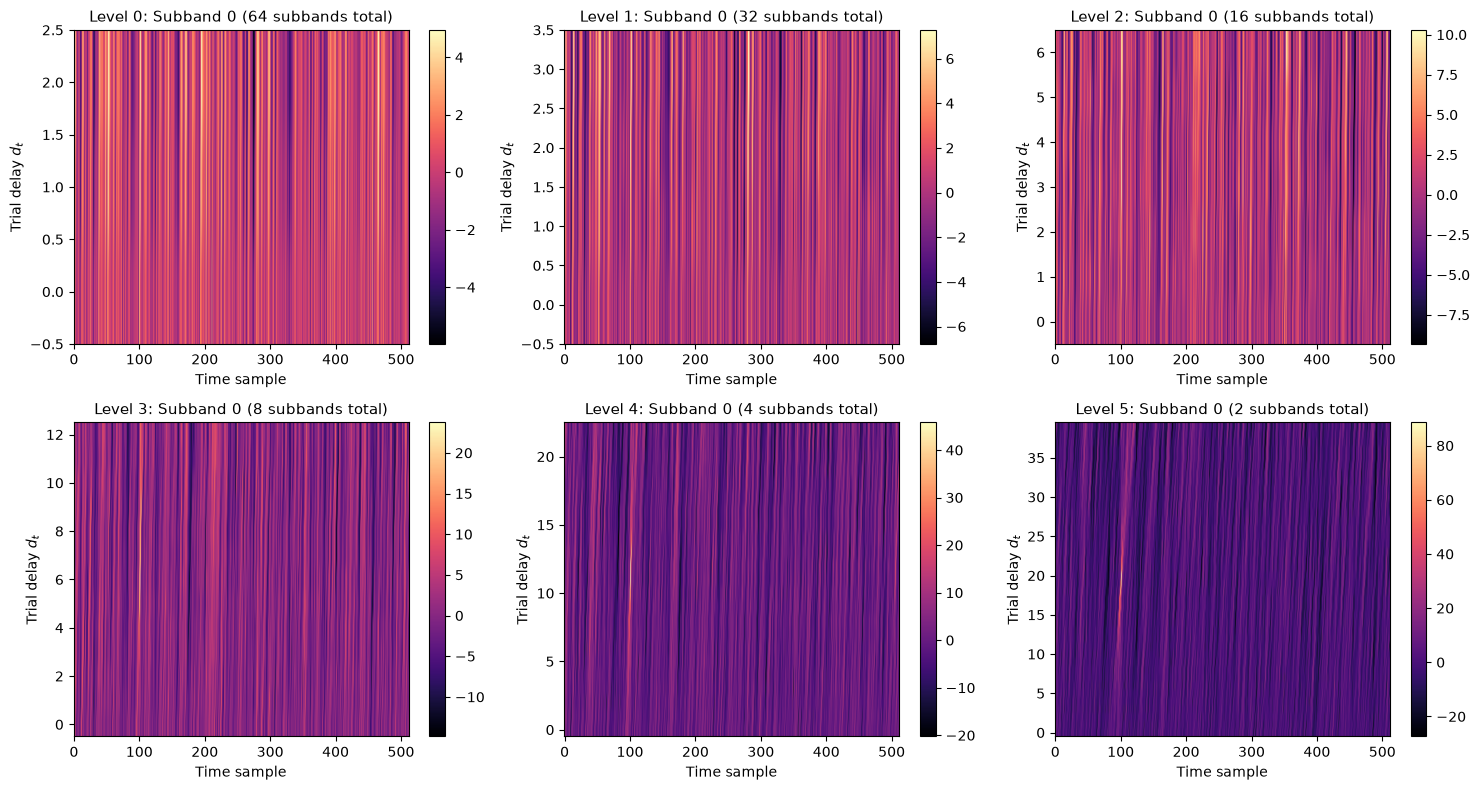

In [3]:
# Visualize the evolution of Subband 0 across tree levels
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Reset and capture subband 0 views at levels 0, 1, 2, 3, 4, 5
fdmt.reset(waterfall)

for lvl in range(min(6, fdmt.total_levels + 1)):
    ax = axes[lvl]
    sub0 = fdmt.view_subband_data(0)
    im = ax.imshow(sub0, aspect="auto", origin="lower", cmap="magma")
    ax.set_title(f"Level {fdmt.current_level}: Subband 0 ({fdmt.num_subbands} subbands total)", fontsize=11)
    ax.set_xlabel("Time sample")
    ax.set_ylabel("Trial delay $d_t$")
    fig.colorbar(im, ax=ax)
    
    if not fdmt.is_finished:
        fdmt.advance(1)

plt.tight_layout()
plt.show()


## 3. Theoretical Noise Calibration

In an incoherent dedispersion search, the input radiometer noise in each channel is independent Gaussian noise with variance $\sigma_0^2$.

However, because the FDMT tree recursively sums overlapping samples, the output noise variance is **not uniform** across all DM trials! Higher DM trials sum over broader dispersion tracks, and the tree sharing causes noise correlation.

To evaluate candidate significance accurately, astronomers must divide the integrated flux by the **exact theoretical noise standard deviation** $\sigma_{\text{eff}}(\text{DM})$ to obtain true Signal-to-Noise Ratio (SNR) units.

DMT computes this analytically from the plan geometry via:
- `fdmt.get_effective_variance(dm_idx, boxcar_width=1)`
- `fdmt.get_effective_sigma(dm_idx, boxcar_width=1)`
- `fdmt.get_effective_sigma_grid(boxcar_width=1)`


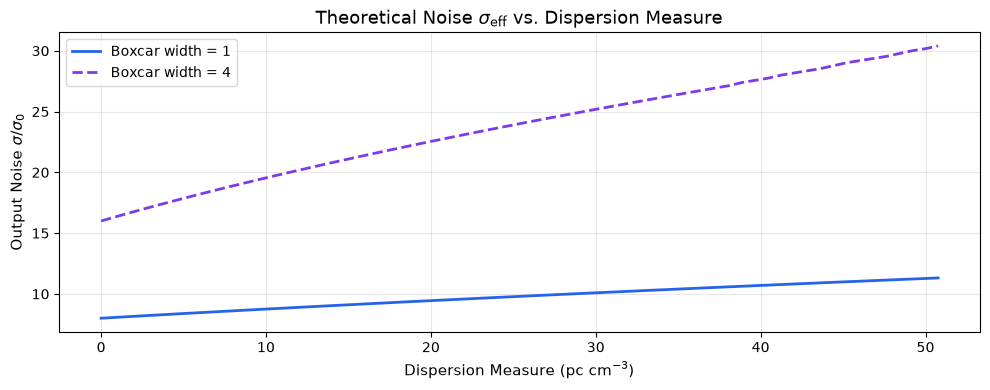

Maximum candidate SNR: nan sigma


/var/folders/gw/_t558hxd7kbd2nyx93sfz3cw0000gp/T/ipykernel_24144/1946281467.py:18: RuntimeWarning: invalid value encountered in divide
  snr_map = dmt_result / sigma_grid_w1[:, np.newaxis]


In [4]:
# Compute theoretical noise sigma across all DM trials
dm_trials = plan.dm_grid_final
sigma_grid_w1 = fdmt.get_effective_sigma_grid(boxcar_width=1)
sigma_grid_w4 = fdmt.get_effective_sigma_grid(boxcar_width=4)

plt.figure(figsize=(10, 4))
plt.plot(dm_trials, sigma_grid_w1, label="Boxcar width = 1", lw=2, color="#2563eb")
plt.plot(dm_trials, sigma_grid_w4, label="Boxcar width = 4", lw=2, color="#7c3aed", linestyle="--")
plt.title("Theoretical Noise $\\sigma_{\\text{eff}}$ vs. Dispersion Measure", fontsize=13)
plt.xlabel("Dispersion Measure (pc cm$^{-3}$)", fontsize=11)
plt.ylabel("Output Noise $\\sigma / \\sigma_0$", fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Calibrate DMT plane to true SNR
snr_map = dmt_result / sigma_grid_w1[:, np.newaxis]
print(f"Maximum candidate SNR: {np.max(snr_map):.2f} sigma")


## Summary

You have learned:
- How the recursive subband tree merges channels in $\mathcal{O}(N_t N_f \log_2 N_f)$ time.
- How to control execution level-by-level with the Stepper API.
- How to inspect intermediate subbands for early candidate triggers or RFI rejection.
- How to normalize the DMT plane into exact SNR units using `get_effective_sigma_grid`.

In **Tutorial 3**, we will look at advanced grid features: **Sparse DM Grids** and **Negative DM Searches**!
